In [1]:
import matplotlib.pyplot as plt
import json
import numpy as np
import pickle as pkl

### Exp 1: XY4

In [2]:
filename = 'exp_data/XY4_ManuallyProcessed.json'
with open(filename, 'r') as file:
    xy4_data = json.load(file)

In [3]:
xy4_data.keys()

dict_keys(['params', 'title', 'startPos', 'posTracking', 'xlabel', 'ylabel', 'datasets'])

In [4]:
xy4_data['datasets'].keys()

dict_keys(['tau_InterPiOver2', 'plusPi/2_cts', 'minusPi/2_cts', 'sumPlusCts', 'sumMinusCts', 'sumDiffs', 'contrasts'])

In [5]:
tau = np.array(xy4_data['datasets']['tau_InterPiOver2'])/1e6 # in ms
contrast = np.array(xy4_data['datasets']['contrasts'])

Text(0, 0.5, 'contrast')

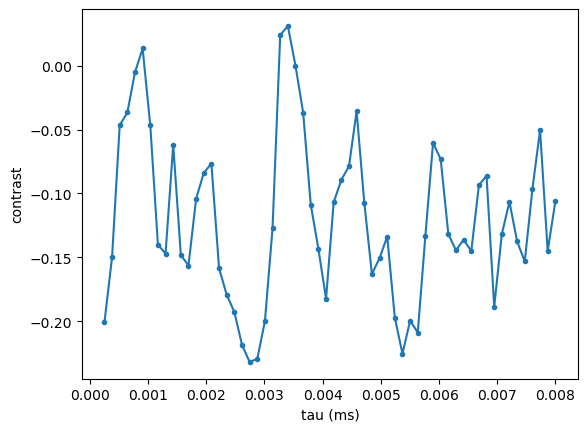

In [6]:
plt.plot(tau, contrast, '.-')
plt.xlabel('tau (ms)')
plt.ylabel('contrast')

In [7]:
scaling = 2/(max(contrast) - min(contrast))
coherence = -(contrast-min(contrast))*scaling+1

Text(0, 0.5, 'coherence')

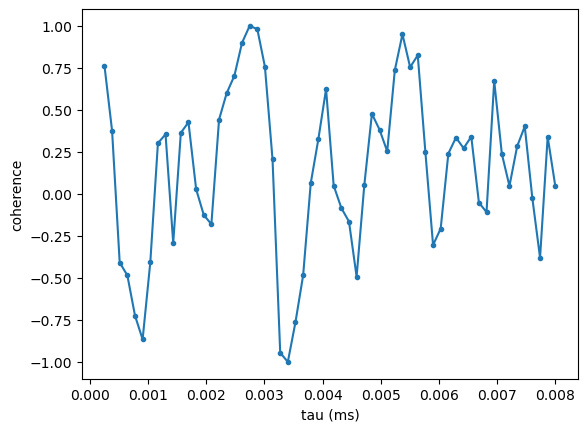

In [8]:
plt.plot(tau, coherence, '.-')
plt.xlabel('tau (ms)')
plt.ylabel('coherence')

In [9]:
with open('exp_data/XY4_exp1_time.pkl', 'wb') as file:
    pkl.dump(np.array(xy4_data['datasets']['tau_InterPiOver2'])/1e6, file)

with open('exp_data/XY4_exp1_coherence.pkl', 'wb') as file:
    pkl.dump(coherence, file)

# Exp 2: XY32

In [10]:
filename = 'exp_data/XY32_ManuallyProcessed.json'
with open(filename, 'r') as file:
    xy32_data = json.load(file)

In [11]:
with open('posterior1_rec_exp2.json', 'r') as file:
    posterior_rec = json.load(file)

Text(0.5, 1.0, '(XY32) raw contrast data')

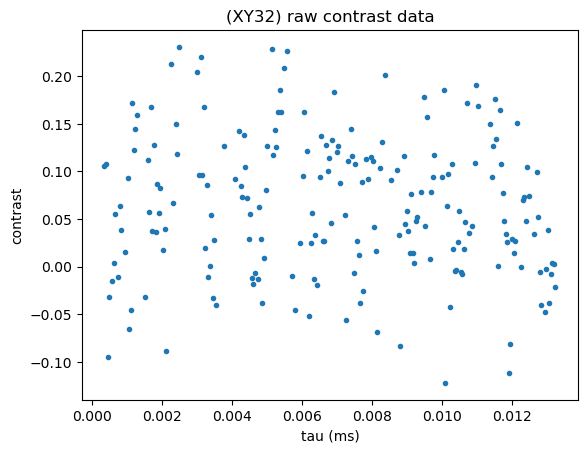

In [12]:
plt.plot(posterior_rec['timepoints'][0], xy32_data['contrasts'], '.')
plt.xlabel('tau (ms)')
plt.ylabel('contrast')
plt.title('(XY32) raw contrast data')

In [13]:
def normalize_contrast_to_coherence_xy32(contrasts):
    contrasts = [contrast*(-1) for contrast in contrasts]
    print(min(contrasts), max(contrasts))
    scaling = 2/(max(contrasts)-min(contrasts))
    coherenceIsh = -(contrasts-min(contrast))*scaling+1
    return coherenceIsh

In [14]:
XY32_coherence = normalize_contrast_to_coherence_xy32(xy32_data['contrasts'])

-0.23073873397647682 0.12207612456747405


Text(0.5, 1.0, 'normalized contrast to coherence')

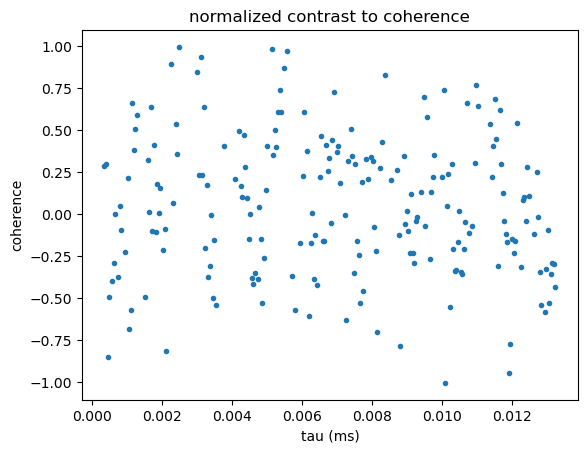

In [15]:
plt.plot(posterior_rec['timepoints'][0], XY32_coherence, '.')
plt.xlabel('tau (ms)')
plt.ylabel('coherence')
plt.title('normalized contrast to coherence')

In [16]:
with open('exp_data/XY32_exp2_time.pkl', 'wb') as file:
    pkl.dump(posterior_rec['timepoints'][0], file)

with open('exp_data/XY32_exp2_coherence.pkl', 'wb') as file:
    pkl.dump(XY32_coherence, file)